# 02 · Results

Can surface nitrate, phosphate and silicate be predicted from Aqua-MODIS ocean-colour products on a 1° grid — and how much of the apparent skill is spatial interpolation? Every cell calls the package in `src/modis_nutrients`; this notebook narrates one run and writes the README figures to `docs/figures/`.

1. Data
2. Spatial correlation and split
3. Model comparison
4. Feature ablation
5. Spatial errors
6. SHAP
7. Seasonal check: July
8. Hyperparameter tuning

In [1]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import sklearn, gstools, optuna, tensorflow as tf

from modis_nutrients.config import REPO_ROOT, load_config
from modis_nutrients.dataset import TableSpec, load_table, spec_from_config
from modis_nutrients.spatial import RandomSplit, SpatialBlockSplit, variogram, nearest_distance_km
from modis_nutrients.models import make_model
from modis_nutrients.evaluate import (run_grid, run_one, headline_table, per_target_table, split_table,
                                      feature_ablation, DEFAULT_ABLATION)
from modis_nutrients.explain import shap_all_targets, mean_abs_shap_table
from modis_nutrients.tuning import tune_optuna
from modis_nutrients.plotting import plot_variogram, plot_split_map, plot_prediction_maps

FIG = REPO_ROOT / "docs" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
print(f"scikit-learn {sklearn.__version__}, tensorflow {tf.__version__}, shap {shap.__version__}, gstools {gstools.__version__}, optuna {optuna.__version__}")

cfg = load_config()
spec = spec_from_config(cfg)
df = load_table(cfg["data"]["path"], spec)
lat, lon = df["lat"].to_numpy(), df["lon"].to_numpy()
Y = df[spec.targets].to_numpy(float)
X = df[["lat", "lon", *spec.features]]

scikit-learn 1.9.0, tensorflow 2.21.0, shap 0.51.0, gstools 1.7.0, optuna 5.0.0


## 1. Data

One row is one 1° ocean cell in January: seven Aqua-MODIS Level-3 monthly-climatology products regridded from 9 km to 1° (inputs) and the WOA13 surface climatology of three nutrients (targets). Land is excluded by requiring the WOA targets; cells with a missing target are dropped, not imputed. The seven inputs are chlorophyll (CHL), phytoplankton absorption at 443 nm (APH), normalised fluorescence line height (FLU), particulate inorganic and organic carbon (PIC, POC), photosynthetically available radiation (PAR) and sea-surface temperature (SST).

In [2]:
print(f"{len(df)} usable cells, months {df.attrs['months']}")
df[[*spec.features, *spec.targets]].agg(["count", "min", "median", "max"]).T.round(3)

33412 usable cells, months [1]


,count,min,median,max
CHL,33412.0,0.008,0.159,14.963
APH,33412.0,0.002,0.013,0.641
FLU,33412.0,0.014,0.081,1.384
PIC,33412.0,0.000,0.000,0.097
POC,33412.0,17.281,55.187,1947.039
PAR,33412.0,3.887,42.243,64.393
SST,33412.0,-1.027,20.838,31.332
nitrate,33412.0,0.000,1.020,33.715
phosphate,33412.0,0.000,0.306,2.606
silicate,33412.0,0.000,2.552,97.694


## 2. Spatial correlation and split

Both inputs and targets are smooth fields, so neighbouring cells are strongly correlated. The semivariogram of the zonally detrended nitrate field (GSTools, great-circle distances, spherical fit) gives the scale: two cells 200 km apart still share most of their residual variance, and the fitted range is about 2000 km.

range 2224 km; shared residual variance at 200 km 82%, at 500 km 63%


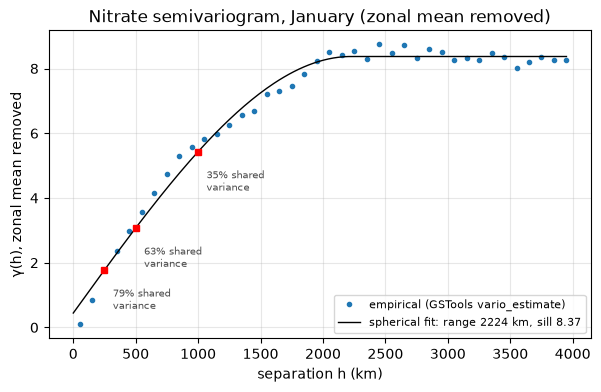

In [3]:
centers, gamma, model = variogram(lat, lon, df["nitrate"], **cfg["variogram"])
sill = model.var + model.nugget
print(f"range {model.len_scale:.0f} km; shared residual variance at 200 km "
      f"{model.var * model.correlation(200) / sill:.0%}, at 500 km {model.var * model.correlation(500) / sill:.0%}")
_ = plot_variogram(centers, gamma, model, title="Nitrate semivariogram, January (zonal mean removed)",
                   path=FIG / "variogram_nitrate.png")
plt.show()

A random split therefore places every test cell next to its training neighbours. Instead, whole 20° tiles are assigned to train / validation / test with `StratifiedGroupKFold` (tile = group, latitude row = stratum; one fold test, one validation, three training), and training cells within 500 km of any held-out cell are removed. The test set is never modified by the buffer; preprocessing is fitted on the training partition only.

{'train': 13562, 'buffer': 8572, 'test': 6305, 'val': 4973}
closest training cell to any test cell: 502 km


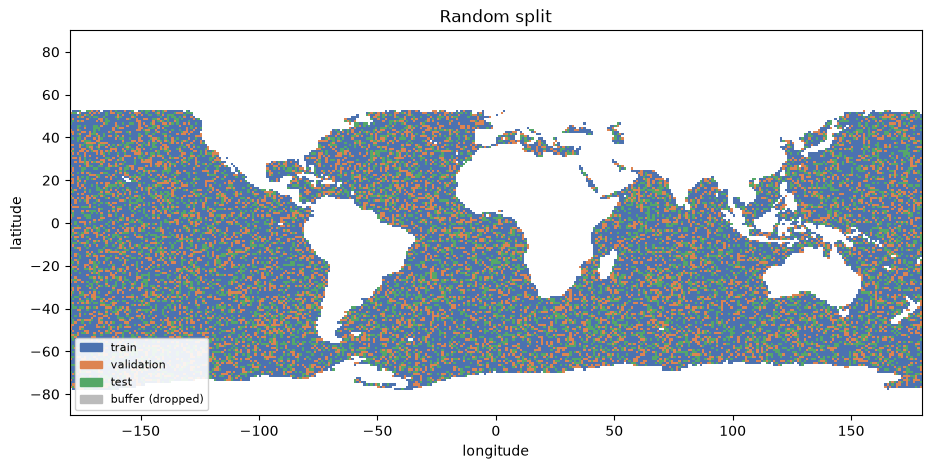

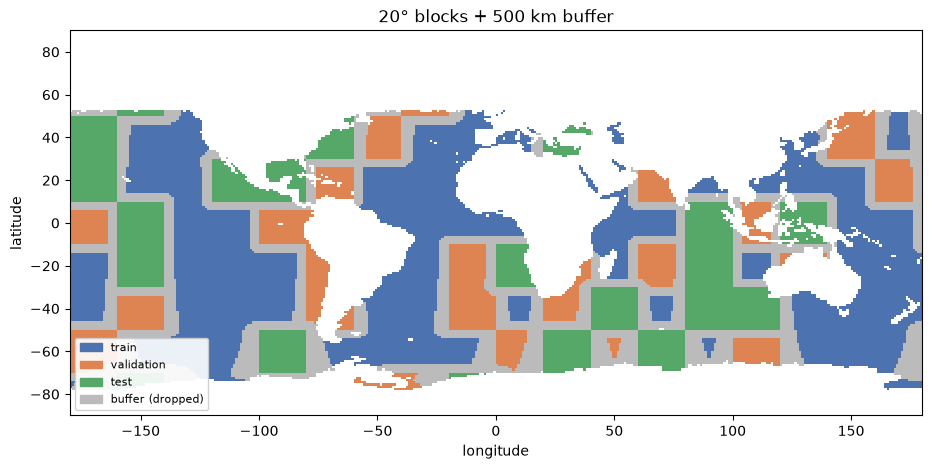

In [4]:
random_split = split_table(RandomSplit(seed=cfg["split"]["seed"]), df)
block_split = split_table(SpatialBlockSplit(cfg["split"]["block_deg"], cfg["split"]["buffer_km"],
                                            seed=cfg["split"]["seed"]), df)
print(pd.Series(block_split.labels()).value_counts().to_dict())
print(f"closest training cell to any test cell: {nearest_distance_km(lat[block_split.train], lon[block_split.train], lat[block_split.test], lon[block_split.test]).min():.0f} km")
_ = plot_split_map(random_split, lat, lon, title="Random split", path=FIG / "split_map_random.png")
_ = plot_split_map(block_split, lat, lon, title="20° blocks + 500 km buffer", path=FIG / "split_map_block_buffer.png")
plt.show()

## 3. Model comparison

Four models are trained and scored under three split strategies. Two of them see only location and are there to detect leakage: if a location-only model scores well, the split is rewarding interpolation between neighbouring cells, and the feature models' scores under that split cannot be trusted.

| Model | Full name | Inputs | How it predicts | Configuration (`configs/default.yaml`) |
|:--|:--|:--|:--|:--|
| `zonal_mean` | zonal-mean baseline | latitude | training-set mean of each nutrient within the cell's latitude band | 5° bands |
| `latlon_knn` | lat/lon k-nearest neighbours | latitude, longitude | distance-weighted mean of the k nearest training cells (great-circle distance) | k = 10 |
| `gbm` | gradient-boosted trees (`HistGradientBoostingRegressor`, one per nutrient) | seven MODIS products | sum of small regression trees fitted to the preprocessed inputs | 500 trees, learning rate 0.05, 31 leaves, L2 = 1.0 |
| `mlp` | multilayer perceptron (TensorFlow / Keras) | seven MODIS products | fully connected network 7 → 64 → 32 → 3, ReLU, MSE loss, Adam | early stopping on the validation partition (patience 25, max 300 epochs) |

Preprocessing for the two feature models: log10 for CHL, APH, PIC and POC, then median imputation and standardisation of all inputs; the three targets are standardised for fitting and mapped back to physical units for scoring. All of it is fitted on the training partition only.

The three split strategies are `random` (60 / 20 / 20 by cell), `block` (whole 20° tiles, stratified by latitude row) and `block_buffer` (the same, plus removal of training cells within 500 km of any held-out cell). Scores are test R², mean over the three nutrients; the second table gives each nutrient separately.

,gbm,latlon_knn,mlp,zonal_mean,n_train,n_val,n_test,n_dropped
split,,,,,,,,
block,0.930,0.877,0.929,0.818,20318,6789,6305,0
block_buffer,0.907,0.727,0.922,0.797,13562,4973,6305,8572
random,0.966,0.998,0.952,0.838,20046,6683,6683,0


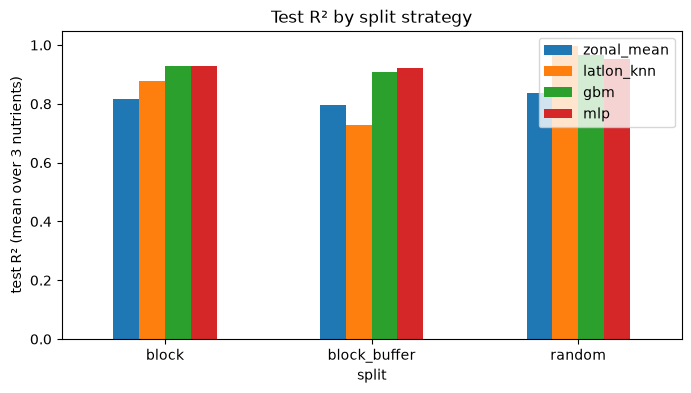

In [6]:
SPLITS = ["random", "block", "block_buffer"]
MODELS = ["zonal_mean", "latlon_knn", "gbm", "mlp"]
long, results = run_grid(cfg, SPLITS, MODELS, df=df, verbose=False)
head = headline_table(long)
display(head.round(3))
ax = head[MODELS].plot.bar(figsize=(8, 4), rot=0, ylabel="test R² (mean over 3 nutrients)",
                           title="Test R² by split strategy")
ax.figure.savefig(FIG / "headline_test_r2.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
per_target_table(long).round(3)

target                   nitrate  phosphate  silicate
split        model                                   
block        gbm           0.969      0.931     0.891
             latlon_knn    0.943      0.905     0.783
             mlp           0.969      0.941     0.877
             zonal_mean    0.915      0.869     0.670
block_buffer gbm           0.965      0.923     0.834
             latlon_knn    0.784      0.701     0.696
             mlp           0.963      0.935     0.866
             zonal_mean    0.904      0.858     0.628
random       gbm           0.979      0.963     0.955
             latlon_knn    0.998      0.997     0.997
             mlp           0.969      0.954     0.934
             zonal_mean    0.895      0.862     0.758

Under the random split the location-only KNN reaches R² ≈ 1 and beats both feature models. Under blocks + buffer it falls to the zonal-mean level while GBM and MLP keep most of their skill. The decrease for GBM/MLP is small compared with the collapse of the KNN: the stricter split removes inflated skill from spatial proximity rather than the MODIS–nutrient relationship. Re-running with another `split.seed` changes which tiles are held out and moves the blocked scores by a few hundredths of R².

## 4. Feature ablation

Same model, same split, four input sets: SST only; SST + PAR; the five ocean-colour products only (CHL, APH, FLU, PIC, POC); all seven. Run for both GBM and MLP under the random and the blocked split, so the conclusion does not depend on one model family. The preprocessing pipeline is rebuilt and refitted on the training partition for each input set.

In [ ]:
ablation_table = pd.concat(
    {model_name: feature_ablation(cfg, ["random", "block_buffer"], DEFAULT_ABLATION, model_name=model_name,
                                  df=df, verbose=False)
     for model_name in ["gbm", "mlp"]},
    axis=1)
ablation_table.round(3)

Under the random split ocean colour appears to add several hundredths of R² on top of SST; under the blocked split the increment is much smaller, and the ocean-colour-only model loses far more between the two splits than the SST-only model. At 1° climatological scale in January, SST captures most of the predictable variance in surface nutrients. Section 7 shows that this is a property of January.

## 5. Spatial errors

Truth, GBM prediction and residual for the three nutrients on the test cells of the blocked split.

In [ ]:
res_gbm = next(r for r in results if r.split_name == "block_buffer" and r.model_name == "gbm")
_ = plot_prediction_maps(lat[block_split.test], lon[block_split.test], Y[block_split.test],
                         res_gbm.predictions["test"], spec.targets,
                         title=f"GBM, January, blocked test cells (test R² = {res_gbm.metrics['test'].loc['mean', 'r2']:.3f})",
                         path=FIG / "test_maps_gbm_january.png")
plt.show()

## 6. SHAP

SHAP values attribute each prediction to the inputs in the units of the target. They are computed on the test cells of the blocked split, so they describe the models in regions they have not seen. GBM uses the exact `TreeExplainer`; the MLP uses the permutation explainer on a 500-cell sample. The table gives mean |SHAP| per input and target for both models; the beeswarm shows the direction for nitrate (each dot is a test cell, colour is the input value, position is its push on the prediction).

PermutationExplainer explainer:  10%|█         | 50/500 [00:11<00:46,  9.65it/s]

PermutationExplainer explainer:  10%|█         | 51/500 [00:11<00:46,  9.71it/s]

PermutationExplainer explainer:  10%|█         | 52/500 [00:11<00:46,  9.73it/s]

PermutationExplainer explainer:  11%|█         | 53/500 [00:11<00:45,  9.75it/s]

PermutationExplainer explainer:  11%|█         | 54/500 [00:11<00:46,  9.57it/s]

...

PermutationExplainer explainer:  99%|█████████▉| 497/500 [00:57<00:00, 10.19it/s]

PermutationExplainer explainer: 100%|█████████▉| 499/500 [00:57<00:00, 10.18it/s]

PermutationExplainer explainer: 501it [00:57, 10.21it/s]                         

PermutationExplainer explainer: 501it [00:57,  8.03it/s]

gbm                        mlp                   
    nitrate phosphate silicate nitrate phosphate silicate
SST   7.391     0.475    9.852   6.951     0.453    8.108
FLU   0.441     0.031    0.471   0.865     0.040    1.875
PAR   0.362     0.023    1.381   0.515     0.033    2.715
CHL   0.317     0.026    0.438   1.307     0.103    4.092
PIC   0.229     0.022    0.871   0.437     0.034    2.261
APH   0.228     0.020    0.520   0.377     0.072    0.598
POC   0.105     0.010    0.305   0.455     0.024    2.682

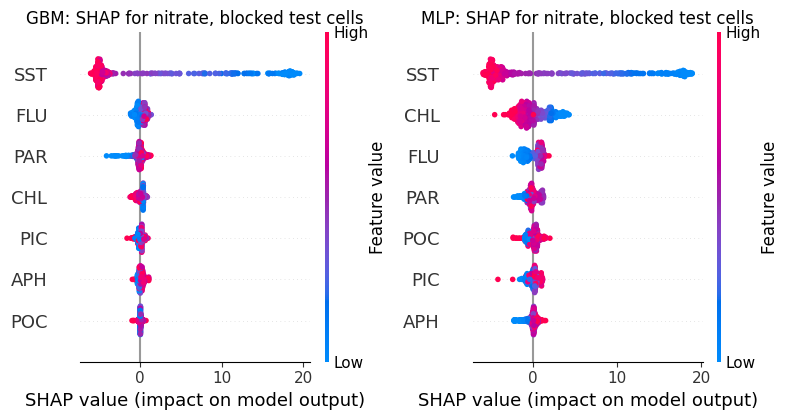

In [ ]:
tr, va, te = block_split.train, block_split.val, block_split.test
shap_ex = {}
for model_name in ["gbm", "mlp"]:
    m = make_model(model_name, cfg).fit(X.iloc[tr], Y[tr], X.iloc[va], Y[va])
    shap_ex[model_name] = shap_all_targets(m, X.iloc[tr], X.iloc[te], max_explain=500)

shap_table = pd.concat({name: mean_abs_shap_table(ex, spec.targets) for name, ex in shap_ex.items()}, axis=1)
display(shap_table.sort_values(("gbm", "nitrate"), ascending=False).round(3))

j = spec.targets.index("nitrate")
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, (model_name, ex) in zip(axes, shap_ex.items()):
    plt.sca(ax)
    shap.plots.beeswarm(ex[..., j], max_display=7, show=False)
    ax.set_title(f"{model_name.upper()}: SHAP for nitrate, blocked test cells")
plt.tight_layout()
fig.savefig(FIG / "shap_beeswarm_nitrate.png", dpi=150, bbox_inches="tight")
plt.show()

SST dominates every nutrient for both models, by an order of magnitude for nitrate, in agreement with the ablation. High SST (red) sits on the negative side: warm, stratified water is nutrient-poor, which is the expected physics. The ocean-colour inputs are mutually correlated, so their small remaining contribution is spread across them.

## 7. Seasonal check: July

The same comparison for July, and for all twelve months pooled with a month hold-out added (train on six months, validate on three, test on three). The `month` split does not block space — a cell's other months stay in the training set — so the KNN score under it is not leakage-free.

In [ ]:
sweep_rows = []
for name, months in {"jan": [1], "jul": [7], "all": list(range(1, 13))}.items():
    cfg["data"]["months"] = months
    splits = ["random", "block_buffer"] + (["month"] if len(months) > 3 else [])
    long_m, _ = run_grid(cfg, splits, ["latlon_knn", "gbm"], verbose=False)
    h = headline_table(long_m)[["latlon_knn", "gbm"]]
    h.insert(0, "months", name)
    sweep_rows.append(h)
cfg["data"]["months"] = list(spec.months)
pd.concat(sweep_rows).round(3)

July scores far lower than January under the blocked split. South of ~50°S there is no July MODIS data (polar night), so the Southern Ocean — the largest and most SST-predictable nutrient signal — is absent, and the standard deviation of nitrate drops from about 9 to about 4 µmol kg⁻¹. R² is relative to that variance; the absolute error barely changes. What remains in July are regimes that SST alone does not explain, and there ocean colour matters.

In [ ]:
rows = []
for m in (1, 7):
    spec_m = TableSpec(spec.features, spec.targets, 0, (m,))
    df_m = load_table(cfg["data"]["path"], spec_m)
    Y_m = df_m[spec.targets].to_numpy(float)
    split_m = split_table(SpatialBlockSplit(cfg["split"]["block_deg"], cfg["split"]["buffer_km"],
                                            seed=cfg["split"]["seed"]), df_m)
    for feats in (["SST"], spec.features):
        cfg_f = {**cfg, "data": {**cfg["data"], "features": feats}}
        r = run_one(df_m, TableSpec(feats, spec.targets, 0, (m,)), split_m, make_model("gbm", cfg_f), "block_buffer")
        rows.append({"month": m, "inputs": "SST only" if len(feats) == 1 else "all seven", "n_cells": len(df_m),
                     "nitrate_std": Y_m[:, 0].std(), "test_r2_nitrate": r.metrics["test"].loc["nitrate", "r2"],
                     "test_rmse_nitrate": r.metrics["test"].loc["nitrate", "rmse"]})
    if m == 7:
        _ = plot_prediction_maps(df_m["lat"].to_numpy()[split_m.test], df_m["lon"].to_numpy()[split_m.test],
                                 Y_m[split_m.test], r.predictions["test"], spec.targets,
                                 title="GBM, July, blocked test cells", path=FIG / "test_maps_gbm_july.png")
        plt.show()
pd.DataFrame(rows).round(2)

The largest July residuals are in the equatorial eastern Pacific (high nutrients at 25 °C, iron-limited; under-predicted), the Arabian Sea monsoon upwelling (under-predicted) and the coastal Gulf of Alaska (over-predicted). Under the blocked split, ocean colour adds several tenths of R² on top of SST in July versus a few hundredths in January: the value of the ocean-colour inputs is regime-dependent, and the January conclusion that SST is sufficient is specific to that month. One January outlier is the Caspian Sea, which WOA13 treats as ocean.

## 8. Hyperparameter tuning

Optuna proposes candidates; each is scored by `GroupKFold` (3 folds) inside the training partition of the blocked split, grouped by 20° block, so tuning cannot favour the candidate that interpolates best. The best candidate is refitted on the full training partition and scored once on the test partition. `cv_r2_std` is the fold-to-fold spread: candidates closer than that cannot be told apart. Search spaces are in `configs/default.yaml` under `tuning:`.

In [4]:
for model_name in ["gbm", "mlp"]:
    trials, best, final = tune_optuna(cfg, "block_buffer", model_name, n_trials=10, df=df, verbose=False)
    print(f"{model_name}: best {best}\n   -> val R² {final.metrics['val'].loc['mean','r2']:.3f}, "
          f"test R² {final.metrics['test'].loc['mean','r2']:.3f}")
    display(trials.head(5).round(3))

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


gbm: best {'max_leaf_nodes': 33, 'learning_rate': 0.05304992753518953, 'l2_regularization': 3.2294705653332807}
   -> val R² 0.851, test R² 0.907


,number,cv_r2_mean,params_l2_regularization,params_learning_rate,params_max_leaf_nodes,user_attrs_cv_r2_std,user_attrs_params
0,1,0.903,3.229,0.053,33,0.023,"{'max_leaf_nodes': 33, 'learning_rate': 0.0530..."
1,5,0.903,4.163,0.021,8,0.023,"{'max_leaf_nodes': 8, 'learning_rate': 0.02095..."
2,0,0.903,3.014,0.104,33,0.023,"{'max_leaf_nodes': 33, 'learning_rate': 0.1038..."
3,8,0.902,0.717,0.087,9,0.024,"{'max_leaf_nodes': 9, 'learning_rate': 0.08728..."
4,2,0.902,4.818,0.156,24,0.023,"{'max_leaf_nodes': 24, 'learning_rate': 0.1558..."


I0000 00:00:1788997019.703419     488 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1788997042.238601     488 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


mlp: best {'hidden': [256, 128, 64], 'learning_rate': 0.0008171478915115864, 'batch_size': 512}
   -> val R² 0.833, test R² 0.915


,number,cv_r2_mean,params_batch_size,params_learning_rate,params_n_layers,params_width,user_attrs_cv_r2_std,user_attrs_params
0,3,0.902,512,0.001,3,256,0.028,"{'hidden': [256, 128, 64], 'learning_rate': 0...."
1,9,0.899,512,0.001,2,64,0.029,"{'hidden': [64, 32], 'learning_rate': 0.001113..."
2,2,0.897,256,0.004,3,64,0.029,"{'hidden': [64, 32, 16], 'learning_rate': 0.00..."
3,4,0.897,128,0.001,2,64,0.031,"{'hidden': [64, 32], 'learning_rate': 0.000748..."
4,5,0.896,256,0.001,3,256,0.030,"{'hidden': [256, 128, 64], 'learning_rate': 0...."


The best trials differ by a few thousandths of R², less than the fold-to-fold spread, and the tuned test scores match the defaults in section 3: neither architecture nor tree size limits these models.

## Takeaways

- Random splitting of a smooth 1° field rewards interpolation; a location-only baseline is the cheapest way to detect it.
- With 20° blocks and a 500 km buffer the feature models keep most of their skill while the location-only models collapse.
- In January, SST alone explains most of the spatially held-out variance; in July, with the Southern Ocean absent, ocean colour adds substantial skill in the iron-limited and upwelling regimes. The value of ocean colour is regime-dependent.
- Hyperparameters chosen by blocked cross-validation do not change these conclusions.